In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# Load dataset
tennis_df = pd.read_csv("tennis_stats.csv")
print(tennis_df.head())
print("Columns In Dataset:", tennis_df.columns.tolist())

                 Player  Year  FirstServe  FirstServePointsWon  \
0           Pedro Sousa  2016        0.88                 0.50   
1       Roman Safiullin  2017        0.84                 0.62   
2           Pedro Sousa  2017        0.83                 0.60   
3   Rogerio Dutra Silva  2010        0.83                 0.64   
4  Daniel Gimeno-Traver  2017        0.81                 0.54   

   FirstServeReturnPointsWon  SecondServePointsWon  \
0                       0.38                  0.50   
1                       0.26                  0.33   
2                       0.28                  0.53   
3                       0.34                  0.59   
4                       0.00                  0.33   

   SecondServeReturnPointsWon  Aces  BreakPointsConverted  BreakPointsFaced  \
0                        0.39     0                  0.14                 7   
1                        0.07     7                  0.00                 7   
2                        0.44     2      

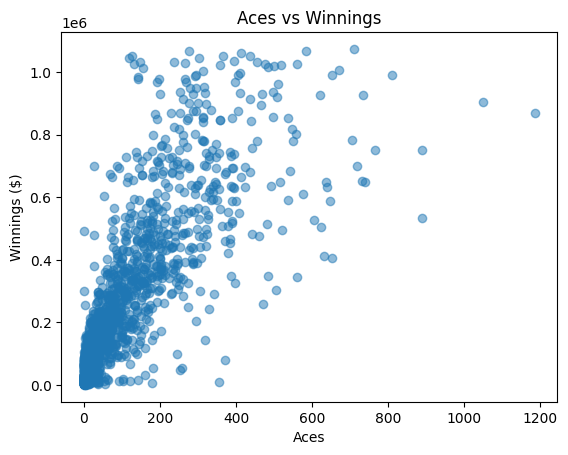

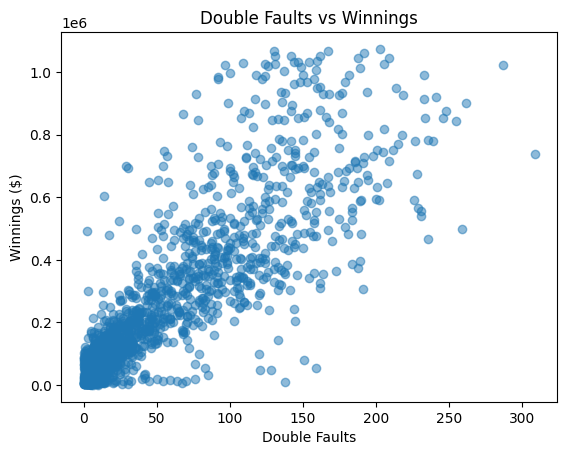

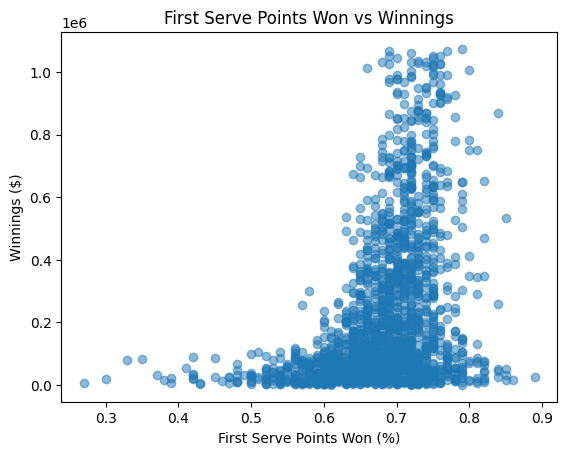

In [3]:
# --- Exploratory Analysis ---
# Service performance vs winnings
plt.scatter(tennis_df['Aces'], tennis_df['Winnings'], alpha=0.5)
plt.xlabel("Aces"); plt.ylabel("Winnings ($)")
plt.title("Aces vs Winnings"); plt.show()

plt.scatter(tennis_df['DoubleFaults'], tennis_df['Winnings'], alpha=0.5)
plt.xlabel("Double Faults"); plt.ylabel("Winnings ($)")
plt.title("Double Faults vs Winnings"); plt.show()

plt.scatter(tennis_df['FirstServePointsWon'], tennis_df['Winnings'], alpha=0.5)
plt.xlabel("First Serve Points Won (%)"); plt.ylabel("Winnings ($)")
plt.title("First Serve Points Won vs Winnings"); plt.show()

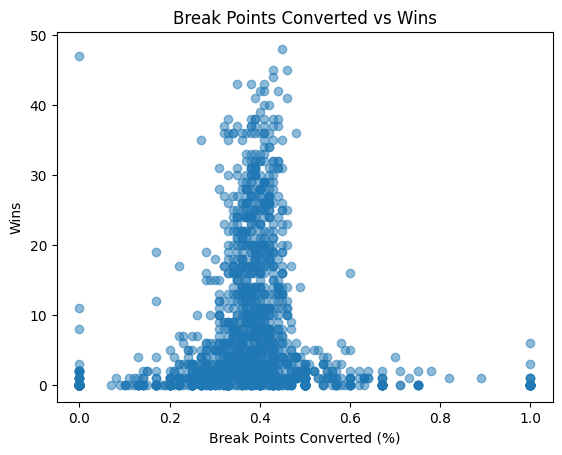

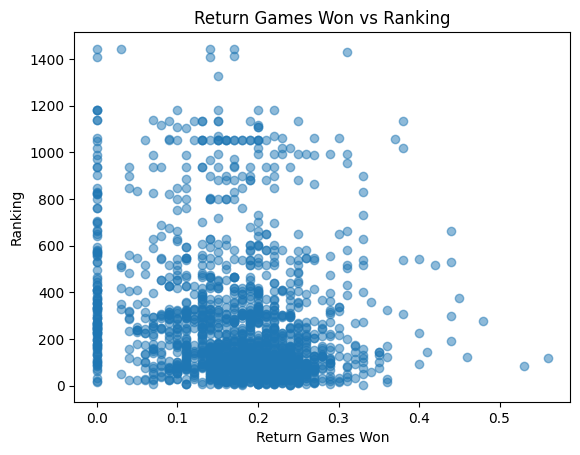

In [4]:
# Percentage features vs outcomes
plt.scatter(tennis_df['BreakPointsConverted'], tennis_df['Wins'], alpha=0.5)
plt.xlabel("Break Points Converted (%)"); plt.ylabel("Wins")
plt.title("Break Points Converted vs Wins"); plt.show()

plt.scatter(tennis_df['ReturnGamesWon'], tennis_df['Ranking'], alpha=0.5)
plt.xlabel("Return Games Won"); plt.ylabel("Ranking")
plt.title("Return Games Won vs Ranking"); plt.show()

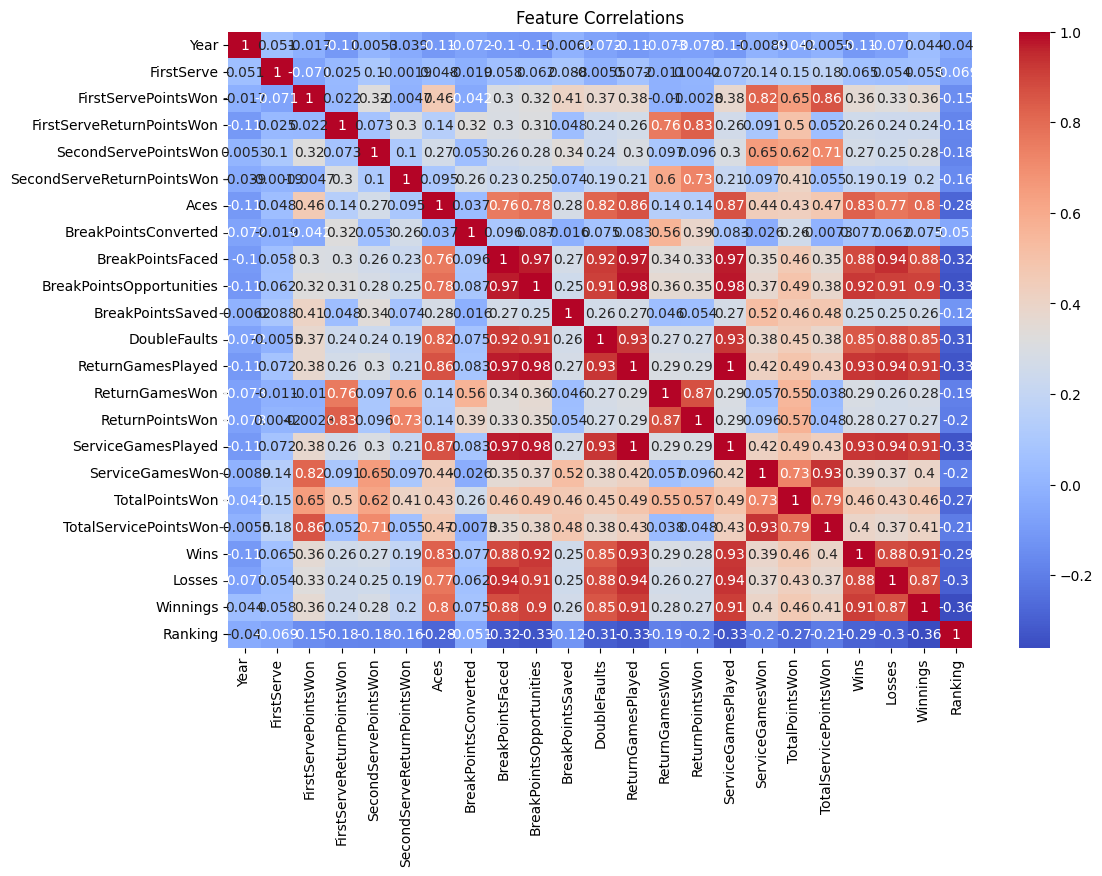

In [10]:
# Correlation heatmap
plt.figure(figsize=(12,8))
numeric_df = tennis_df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlations"); plt.show()

In [9]:
# --- Single Feature Linear Regressions ---
features = ['Ranking','Wins','Aces','BreakPointsConverted']
for f in features:
    X = tennis_df[[f]]
    y = tennis_df[['Winnings']]
    x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    model = LinearRegression().fit(x_train,y_train)
    print(f"{f} → Train R²: {model.score(x_train,y_train):.3f}, Test R²: {model.score(x_test,y_test):.3f}")

Ranking → Train R²: 0.122, Test R²: 0.159
Wins → Train R²: 0.832, Test R²: 0.842
Aces → Train R²: 0.646, Test R²: 0.594
BreakPointsConverted → Train R²: 0.006, Test R²: 0.002


In [11]:
# --- Two Feature Linear Regressions ---
pairs = [
    ['Wins','Ranking'],
    ['Aces','Wins'],
    ['BreakPointsConverted','Ranking'],
    ['FirstServePointsWon','Wins'],
    ['BreakPointsOpportunities','FirstServeReturnPointsWon']
]
for p in pairs:
    X = tennis_df[p]
    y = tennis_df[['Winnings']]
    x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    model = LinearRegression().fit(x_train,y_train)
    print(f"{p} → Train R²: {model.score(x_train,y_train):.3f}, Test R²: {model.score(x_test,y_test):.3f}")

['Wins', 'Ranking'] → Train R²: 0.842, Test R²: 0.855
['Aces', 'Wins'] → Train R²: 0.839, Test R²: 0.846
['BreakPointsConverted', 'Ranking'] → Train R²: 0.127, Test R²: 0.154
['FirstServePointsWon', 'Wins'] → Train R²: 0.834, Test R²: 0.844
['BreakPointsOpportunities', 'FirstServeReturnPointsWon'] → Train R²: 0.818, Test R²: 0.789


In [12]:
X = tennis_df[['Wins','Ranking','Aces','BreakPointsConverted','FirstServePointsWon','ReturnGamesWon']]
y = tennis_df[['Winnings']]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression().fit(x_train,y_train)
print("Multi-feature (selected) → Train R²:", model.score(x_train,y_train), "Test R²:", model.score(x_test,y_test))
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.2f}")


Multi-feature (selected) → Train R²: 0.8479126615521966 Test R²: 0.85861900432354
Wins: 18924.38
Ranking: -85.64
Aces: 254.38
BreakPointsConverted: -492.79
FirstServePointsWon: 45827.89
ReturnGamesWon: 67315.76


In [13]:

# --- Multiple Feature Linear Regression (full set) ---
X = tennis_df[['FirstServe','FirstServePointsWon','FirstServeReturnPointsWon',
               'SecondServePointsWon','SecondServeReturnPointsWon','Aces',
               'BreakPointsConverted','BreakPointsFaced','BreakPointsOpportunities',
               'BreakPointsSaved','DoubleFaults','ReturnGamesPlayed','ReturnGamesWon',
               'ReturnPointsWon','ServiceGamesPlayed','ServiceGamesWon','TotalPointsWon',
               'TotalServicePointsWon']]
y = tennis_df[['Winnings']]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression().fit(x_train,y_train)
print("Multi-feature (full set) → Train R²:", model.score(x_train,y_train), "Test R²:", model.score(x_test,y_test))
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.2f}")

Multi-feature (full set) → Train R²: 0.8448655859314528 Test R²: 0.8268140857573162
FirstServe: 30815.72
FirstServePointsWon: 146614.91
FirstServeReturnPointsWon: -25812.85
SecondServePointsWon: 83893.96
SecondServeReturnPointsWon: -1221.70
Aces: -165.03
BreakPointsConverted: -3617.09
BreakPointsFaced: -1105.64
BreakPointsOpportunities: 681.45
BreakPointsSaved: 51577.45
DoubleFaults: 492.87
ReturnGamesPlayed: 83.00
ReturnGamesWon: 113441.12
ReturnPointsWon: -67037.13
ServiceGamesPlayed: 1141.38
ServiceGamesWon: -19361.28
TotalPointsWon: -188104.38
TotalServicePointsWon: -119388.13
